--- Stock Data (first few rows) ---
        Date       Close        High         Low        Open     Volume
0 2021-01-25  293.600006  300.133331  279.606659  285.000000  123520200
1 2021-01-26  294.363342  298.633331  290.533325  297.126678   69394800
2 2021-01-27  288.053345  297.166656  286.220001  290.116669   82002000
3 2021-01-28  278.476654  282.666656  267.000000  273.333344   79134000
4 2021-01-29  264.510010  280.803345  260.033325  276.666656  104972400 

--- Precomputed Sentiment Data (first few rows) ---
        Date  next_day_sentiment
0 2021-01-25            0.000000
1 2021-01-26            0.000000
2 2021-01-27            0.999931
3 2021-01-28            0.733300
4 2021-01-29           -0.998794 

Confusion Matrix (numeric):
[[374 130]
 [379 139]]
Accuracy: 0.50


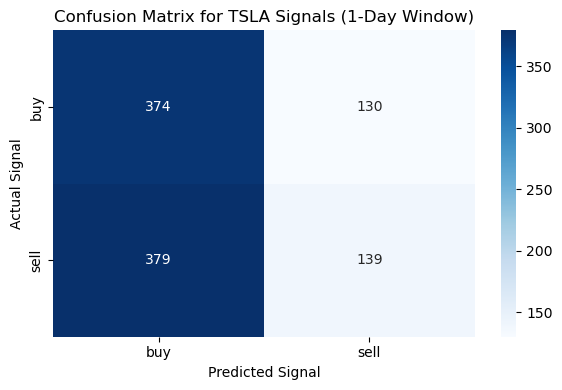

In [1]:
import sys
import os

# Get the absolute path to the `src` directory
src_path = os.path.abspath(os.path.join('..', 'src'))

# Add the `src` directory to the Python path
if src_path not in sys.path:
    sys.path.append(src_path)

import random
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------------------------
# Helper function: convert a sentiment score to a signal
# ---------------------------------------------------------------------------------
def get_predicted_signal(sentiment):
    """
    Convert a numeric sentiment score into a discrete signal.
      - sentiment > 0 => 'buy'
      - sentiment < 0 => 'sell'
      - sentiment = 0 => random choice of 'buy' or 'sell'
    """
    if sentiment > 0:
        return "buy"
    elif sentiment < 0:
        return "sell"
    else:
        return random.choice(["buy", "sell"])

# ---------------------------------------------------------------------------------
# Helper function: derive the actual stock signal from Open and Close prices
# ---------------------------------------------------------------------------------
def get_actual_signal(row):
    """
    If Close > Open, then 'buy' (price went up); otherwise 'sell'.
    """
    return "buy" if row['Close'] > row['Open'] else "sell"

# ---------------------------------------------------------------------------------
# Main script
# ---------------------------------------------------------------------------------
    # 1) Read your stock data CSV (with TSLA price history).
    #    You mentioned you skip the first 3 rows (extra headers) and then rename columns:
csv_file = "TSLA_NLP_data.csv"
stock_df = pd.read_csv(csv_file, skiprows=3, header=None)
stock_df.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]
    
    # Convert the Date column to datetime and normalize (remove any time component).
stock_df['Date'] = pd.to_datetime(stock_df['Date']).dt.normalize()
stock_df = stock_df.reset_index(drop=True)

print("--- Stock Data (first few rows) ---")
print(stock_df.head(), "\n")

    # 2) Read the **pre-computed** next-day sentiment CSV you provided (1-day rollback).
    #    It has columns: "Date,next_day_sentiment"
sentiment_csv = "tsla_next_day_sentiment_1day.csv"
sentiment_df = pd.read_csv(sentiment_csv)

    # Convert the Date column to datetime and normalize
sentiment_df['Date'] = pd.to_datetime(sentiment_df['Date']).dt.normalize()

print("--- Precomputed Sentiment Data (first few rows) ---")
print(sentiment_df.head(), "\n")

    # 3) Merge the sentiment dataframe with your stock dataframe on the Date.
    #    We'll only keep columns: ['Date', 'Open', 'Close'] from the stock data.
merged_df = pd.merge(
    sentiment_df, 
    stock_df[['Date', 'Open', 'Close']], 
    on='Date', 
    how='inner'
)

    # 4) Create predicted signals and actual signals
merged_df['predicted_signal'] = merged_df['next_day_sentiment'].apply(get_predicted_signal)
merged_df['actual_signal'] = merged_df.apply(get_actual_signal, axis=1)

    # 5) Compute confusion matrix and accuracy
labels = ["buy", "sell"]
cm = confusion_matrix(merged_df['actual_signal'], merged_df['predicted_signal'], labels=labels)
acc = accuracy_score(merged_df['actual_signal'], merged_df['predicted_signal'])

print("Confusion Matrix (numeric):")
print(cm)
print(f"Accuracy: {acc:.2f}")

    # 6. Plot confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=labels, yticklabels=labels)

plt.title("Confusion Matrix for TSLA Signals (1-Day Window)")
plt.ylabel("Actual Signal")
plt.xlabel("Predicted Signal")
plt.tight_layout()
plt.show()

--- Stock Data (first few rows) ---
        Date       Close        High         Low        Open     Volume
0 2021-01-25  293.600006  300.133331  279.606659  285.000000  123520200
1 2021-01-26  294.363342  298.633331  290.533325  297.126678   69394800
2 2021-01-27  288.053345  297.166656  286.220001  290.116669   82002000
3 2021-01-28  278.476654  282.666656  267.000000  273.333344   79134000
4 2021-01-29  264.510010  280.803345  260.033325  276.666656  104972400 

--- Precomputed Sentiment Data (first few rows) ---
        Date  next_day_sentiment
0 2021-01-29            0.146888
1 2021-01-30            0.146888
2 2021-01-31            0.146888
3 2021-02-01           -0.053099
4 2021-02-02           -0.199759 

Confusion Matrix (numeric):
[[411  91]
 [408 108]]
Accuracy: 0.51


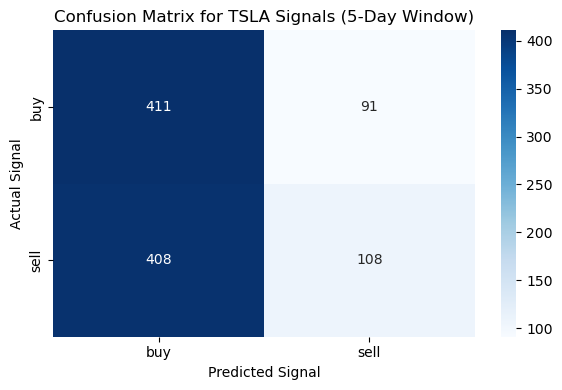

In [5]:
csv_file = "TSLA_NLP_data.csv"
stock_df = pd.read_csv(csv_file, skiprows=3, header=None)
stock_df.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]
    
    # Convert the Date column to datetime and normalize (remove any time component).
stock_df['Date'] = pd.to_datetime(stock_df['Date']).dt.normalize()
stock_df = stock_df.reset_index(drop=True)

print("--- Stock Data (first few rows) ---")
print(stock_df.head(), "\n")

    # 2) Read the **pre-computed** next-day sentiment CSV you provided (1-day rollback).
    #    It has columns: "Date,next_day_sentiment"
sentiment_csv = "tsla_next_day_sentiment_5day.csv"
sentiment_df = pd.read_csv(sentiment_csv)

    # Convert the Date column to datetime and normalize
sentiment_df['Date'] = pd.to_datetime(sentiment_df['Date']).dt.normalize()

print("--- Precomputed Sentiment Data (first few rows) ---")
print(sentiment_df.head(), "\n")

merged_df = pd.merge(
    sentiment_df, 
    stock_df[['Date', 'Open', 'Close']], 
    on='Date', 
    how='inner'
)

    # 4) Create predicted signals and actual signals
merged_df['predicted_signal'] = merged_df['next_day_sentiment'].apply(get_predicted_signal)
merged_df['actual_signal'] = merged_df.apply(get_actual_signal, axis=1)

    # 5) Compute confusion matrix and accuracy
labels = ["buy", "sell"]
cm = confusion_matrix(merged_df['actual_signal'], merged_df['predicted_signal'], labels=labels)
acc = accuracy_score(merged_df['actual_signal'], merged_df['predicted_signal'])

print("Confusion Matrix (numeric):")
print(cm)
print(f"Accuracy: {acc:.2f}")

    # 6. Plot confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=labels, yticklabels=labels)

plt.title("Confusion Matrix for TSLA Signals (5-Day Window)")
plt.ylabel("Actual Signal")
plt.xlabel("Predicted Signal")
plt.tight_layout()
plt.show()


--- Stock Data (first few rows) ---
        Date       Close        High         Low        Open     Volume
0 2021-01-25  293.600006  300.133331  279.606659  285.000000  123520200
1 2021-01-26  294.363342  298.633331  290.533325  297.126678   69394800
2 2021-01-27  288.053345  297.166656  286.220001  290.116669   82002000
3 2021-01-28  278.476654  282.666656  267.000000  273.333344   79134000
4 2021-01-29  264.510010  280.803345  260.033325  276.666656  104972400 

--- Precomputed Sentiment Data (first few rows) ---
        Date  next_day_sentiment
0 2021-02-08            0.115562
1 2021-02-09            0.115562
2 2021-02-10            0.115573
3 2021-02-11            0.048911
4 2021-02-12            0.000025 

Confusion Matrix (numeric):
[[415  84]
 [410 103]]
Accuracy: 0.51


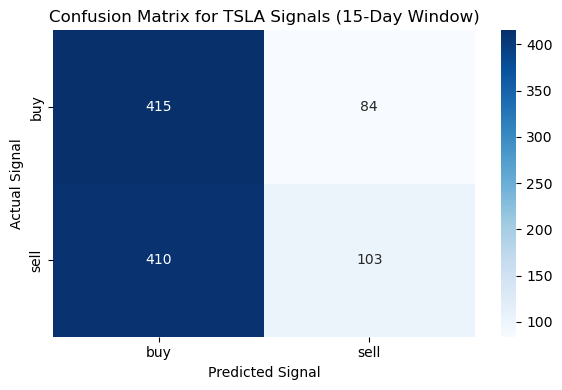

In [6]:
csv_file = "TSLA_NLP_data.csv"
stock_df = pd.read_csv(csv_file, skiprows=3, header=None)
stock_df.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]
    
    # Convert the Date column to datetime and normalize (remove any time component).
stock_df['Date'] = pd.to_datetime(stock_df['Date']).dt.normalize()
stock_df = stock_df.reset_index(drop=True)

print("--- Stock Data (first few rows) ---")
print(stock_df.head(), "\n")

    # 2) Read the **pre-computed** next-day sentiment CSV you provided (1-day rollback).
    #    It has columns: "Date,next_day_sentiment"
sentiment_csv = "tsla_next_day_sentiment_15day.csv"
sentiment_df = pd.read_csv(sentiment_csv)

    # Convert the Date column to datetime and normalize
sentiment_df['Date'] = pd.to_datetime(sentiment_df['Date']).dt.normalize()

print("--- Precomputed Sentiment Data (first few rows) ---")
print(sentiment_df.head(), "\n")
merged_df = pd.merge(
    sentiment_df, 
    stock_df[['Date', 'Open', 'Close']], 
    on='Date', 
    how='inner'
)

    # 4) Create predicted signals and actual signals
merged_df['predicted_signal'] = merged_df['next_day_sentiment'].apply(get_predicted_signal)
merged_df['actual_signal'] = merged_df.apply(get_actual_signal, axis=1)

    # 5) Compute confusion matrix and accuracy
labels = ["buy", "sell"]
cm = confusion_matrix(merged_df['actual_signal'], merged_df['predicted_signal'], labels=labels)
acc = accuracy_score(merged_df['actual_signal'], merged_df['predicted_signal'])

print("Confusion Matrix (numeric):")
print(cm)
print(f"Accuracy: {acc:.2f}")

    # 6. Plot confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=labels, yticklabels=labels)

plt.title("Confusion Matrix for TSLA Signals (15-Day Window)")
plt.ylabel("Actual Signal")
plt.xlabel("Predicted Signal")
plt.tight_layout()
plt.show()

--- Stock Data (first few rows) ---
        Date       Close        High         Low        Open     Volume
0 2021-01-25  293.600006  300.133331  279.606659  285.000000  123520200
1 2021-01-26  294.363342  298.633331  290.533325  297.126678   69394800
2 2021-01-27  288.053345  297.166656  286.220001  290.116669   82002000
3 2021-01-28  278.476654  282.666656  267.000000  273.333344   79134000
4 2021-01-29  264.510010  280.803345  260.033325  276.666656  104972400 

--- Precomputed Sentiment Data (first few rows) ---
        Date  next_day_sentiment
0 2021-01-29            0.062602
1 2021-01-30            0.013639
2 2021-01-31           -0.035323
3 2021-02-01           -0.084286
4 2021-02-02           -0.066586 

Confusion Matrix (numeric):
[[407  95]
 [403 113]]
Accuracy: 0.51


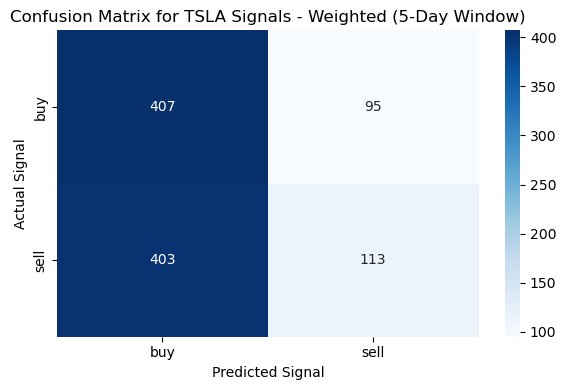

In [7]:
csv_file = "TSLA_NLP_data.csv"
stock_df = pd.read_csv(csv_file, skiprows=3, header=None)
stock_df.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]
    
    # Convert the Date column to datetime and normalize (remove any time component).
stock_df['Date'] = pd.to_datetime(stock_df['Date']).dt.normalize()
stock_df = stock_df.reset_index(drop=True)

print("--- Stock Data (first few rows) ---")
print(stock_df.head(), "\n")

    # 2) Read the **pre-computed** next-day sentiment CSV you provided (1-day rollback).
    #    It has columns: "Date,next_day_sentiment"
sentiment_csv = "tsla_next_day_weight_sentiment_5day.csv"
sentiment_df = pd.read_csv(sentiment_csv)

    # Convert the Date column to datetime and normalize
sentiment_df['Date'] = pd.to_datetime(sentiment_df['Date']).dt.normalize()

print("--- Precomputed Sentiment Data (first few rows) ---")
print(sentiment_df.head(), "\n")
merged_df = pd.merge(
    sentiment_df, 
    stock_df[['Date', 'Open', 'Close']], 
    on='Date', 
    how='inner'
)

merged_df['predicted_signal'] = merged_df['next_day_sentiment'].apply(get_predicted_signal)
merged_df['actual_signal'] = merged_df.apply(get_actual_signal, axis=1)

    # 5) Compute confusion matrix and accuracy
labels = ["buy", "sell"]
cm = confusion_matrix(merged_df['actual_signal'], merged_df['predicted_signal'], labels=labels)
acc = accuracy_score(merged_df['actual_signal'], merged_df['predicted_signal'])

print("Confusion Matrix (numeric):")
print(cm)
print(f"Accuracy: {acc:.2f}")

    # 6. Plot confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=labels, yticklabels=labels)

plt.title("Confusion Matrix for TSLA Signals - Weighted (5-Day Window)")
plt.ylabel("Actual Signal")
plt.xlabel("Predicted Signal")
plt.tight_layout()
plt.show()

--- Stock Data (first few rows) ---
        Date       Close        High         Low        Open     Volume
0 2021-01-25  293.600006  300.133331  279.606659  285.000000  123520200
1 2021-01-26  294.363342  298.633331  290.533325  297.126678   69394800
2 2021-01-27  288.053345  297.166656  286.220001  290.116669   82002000
3 2021-01-28  278.476654  282.666656  267.000000  273.333344   79134000
4 2021-01-29  264.510010  280.803345  260.033325  276.666656  104972400 

--- Precomputed Sentiment Data (first few rows) ---
        Date  next_day_sentiment
0 2021-02-08            0.099400
1 2021-02-09            0.084955
2 2021-02-10            0.070530
3 2021-02-11            0.056083
4 2021-02-12            0.049969 

Confusion Matrix (numeric):
[[415  84]
 [411 102]]
Accuracy: 0.51


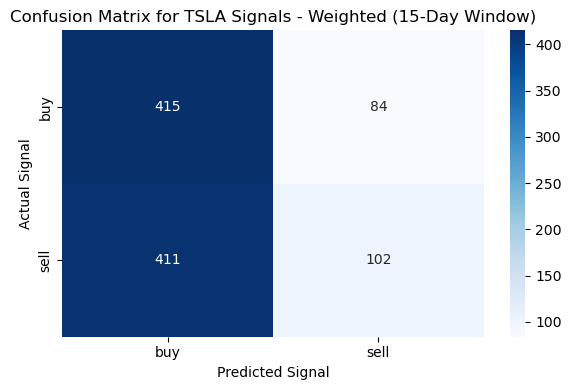

In [9]:
csv_file = "TSLA_NLP_data.csv"
stock_df = pd.read_csv(csv_file, skiprows=3, header=None)
stock_df.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]
    
    # Convert the Date column to datetime and normalize (remove any time component).
stock_df['Date'] = pd.to_datetime(stock_df['Date']).dt.normalize()
stock_df = stock_df.reset_index(drop=True)

print("--- Stock Data (first few rows) ---")
print(stock_df.head(), "\n")

    # 2) Read the **pre-computed** next-day sentiment CSV you provided (1-day rollback).
    #    It has columns: "Date,next_day_sentiment"
sentiment_csv = "tsla_next_day_weight_sentiment_15day.csv"
sentiment_df = pd.read_csv(sentiment_csv)

    # Convert the Date column to datetime and normalize
sentiment_df['Date'] = pd.to_datetime(sentiment_df['Date']).dt.normalize()

print("--- Precomputed Sentiment Data (first few rows) ---")
print(sentiment_df.head(), "\n")
merged_df = pd.merge(
    sentiment_df, 
    stock_df[['Date', 'Open', 'Close']], 
    on='Date', 
    how='inner'
)

merged_df['predicted_signal'] = merged_df['next_day_sentiment'].apply(get_predicted_signal)
merged_df['actual_signal'] = merged_df.apply(get_actual_signal, axis=1)

    # 5) Compute confusion matrix and accuracy
labels = ["buy", "sell"]
cm = confusion_matrix(merged_df['actual_signal'], merged_df['predicted_signal'], labels=labels)
acc = accuracy_score(merged_df['actual_signal'], merged_df['predicted_signal'])

print("Confusion Matrix (numeric):")
print(cm)
print(f"Accuracy: {acc:.2f}")

    # 6. Plot confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=labels, yticklabels=labels)

plt.title("Confusion Matrix for TSLA Signals - Weighted (15-Day Window)")
plt.ylabel("Actual Signal")
plt.xlabel("Predicted Signal")
plt.tight_layout()
plt.show()